# Model Training Pipeline - Chicago Rideshare Demand Forecasting

```markdown
Prediction Targets:
 - T1: Citywide hourly demand (regression)
 - T2: Driver repositioning (classification)
 - T3: Per H3 cell demand (regression)
 - T4: Surge detection (binary classification)
```

In [36]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')


from matplotlib.patches import Patch
from sklearn.metrics import confusion_matrix

from optuna.importance import get_param_importances

sys.path.append("/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting")
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))

from src.config import (TARGETS, MODELS_DIR, RANDOM_STATE, load_feature_registry, get_feature_columns)
from src.data.loader import (load_citywide_data, load_h3_data, temporal_split_citywide, temporal_split_h3, prepare_xy)
from src.features.build_features import (get_feature_groups, select_features, validate_features)
from src.models.baselines import (run_regression_baselines, run_classification_baselines)
from src.models.trainer import (train_xgboost, train_lightgbm, train_tuned_model, save_best_model, setup_mlflow)
from src.models.evaluation import (compute_metrics, format_metrics_table, log_metrics)
from src.utils.logging_config import setup_logging
from src.models.tuner import (xgboost_regression_objective, xgboost_classification_objective, lightgbm_regression_objective, lightgbm_classification_objective, run_optuna_study)


In [2]:
logger = setup_logging('notebook.training')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11
})

#### Load files

In [3]:
registry = load_feature_registry()
df_city = load_citywide_data()
print(f" Target (primary): {registry['target_primary']}")
print(f" Target (next hour): {registry['target_next_hour']}")
print(f" Target (surge): {registry['target_surge']}")
print(f" Target (reposition): {registry['target_reposition']}")

df_city.head(3)

18:29:39 │ INFO     │ data.loader │ Loading citywide data from /Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/processed/chirde.citywide_hourly.parquet
18:29:39 │ INFO     │ data.loader │ Raw columns: ['hour_bucket', 'trip_count', 'avg_fare', 'avg_duration_sec', 'avg_distance', 'shared_pct', 'avg_tip', 'unique_areas', 'unique_h3_cells', 'hour']... (95 total)
18:29:39 │ INFO     │ data.loader │ Found datetime column: 'hour_bucket'
 Target (primary): trip_count
 Target (next hour): target_1h
 Target (surge): is_surge
 Target (reposition): reposition_signal


,trip_count,avg_fare,avg_duration_sec,avg_distance,shared_pct,avg_tip,unique_areas,unique_h3_cells,hour,day_of_week,...,is_snowing,weather_misery,date_y,cta_total_rides,cta_avg_ratio,cta_stations_low,is_surge,target_1h,target_2h,target_3h
hour_bucket,,,,,,,,,,,,,,,,,,,,,
2024-12-01 00:00:00,8370,9.428017,548.647644,2.935735,0.035245,0.616010,78,337,0,6,...,0,0.3265,2024-12-01,150000,0.914969,6,0,6510.0,4982.0,3170.0
2024-12-01 01:00:00,6510,9.882873,542.183899,3.069201,0.035330,0.588326,78,257,1,6,...,0,0.3295,2024-12-01,150000,0.914969,6,0,4982.0,3170.0,2208.0
2024-12-01 02:00:00,4982,11.844641,551.633057,3.171457,0.036933,0.596146,78,219,2,6,...,0,0.3319,2024-12-01,150000,0.914969,6,0,3170.0,2208.0,1831.0


#### Train/Test split

18:29:39 │ INFO     │ data.loader │ Temporal split (citywide):
18:29:39 │ INFO     │ data.loader │   Train: 528 rows
18:29:39 │ INFO     │ data.loader │   Val:   120 rows
18:29:39 │ INFO     │ data.loader │   Test:  96 rows
18:29:39 │ INFO     │ data.loader │   Train: 2024-12-01 00:00:00 to 2024-12-22 23:00:00
18:29:39 │ INFO     │ data.loader │   Val: 2024-12-23 00:00:00 to 2024-12-27 23:00:00
18:29:39 │ INFO     │ data.loader │   Test: 2024-12-28 00:00:00 to 2024-12-31 23:00:00
Citywide data shapes - Train: (528, 94), Val: (120, 94), Test: (96, 94)


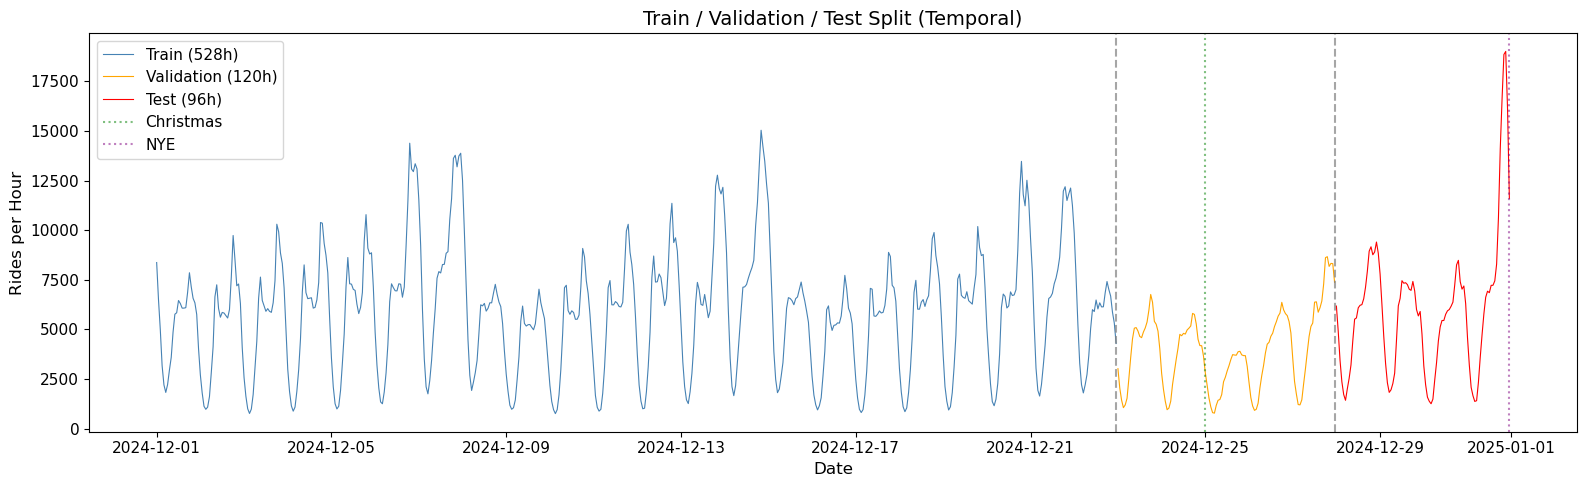

In [4]:
train_city, val_city, test_city = temporal_split_citywide(df_city)
print(f"Citywide data shapes - Train: {train_city.shape}, Val: {val_city.shape}, Test: {test_city.shape}")

fig, ax = plt.subplots(figsize=(16, 5))

if "trip_count" in train_city.columns:
    ax.plot(train_city.index, train_city["trip_count"], color="steelblue", label=f"Train ({len(train_city)}h)", linewidth=0.8)
    ax.plot(val_city.index, val_city["trip_count"], color="orange", label=f"Validation ({len(val_city)}h)", linewidth=0.8)
    ax.plot(test_city.index, test_city["trip_count"], color="red", label=f"Test ({len(test_city)}h)", linewidth=0.8)
elif "target_1h" in train_city.columns:
    ax.plot(train_city.index, train_city["target_1h"], color="steelblue", label=f"Train ({len(train_city)}h)", linewidth=0.8)
    ax.plot(val_city.index, val_city["target_1h"], color="orange", label=f"Validation ({len(val_city)}h)", linewidth=0.8)
    ax.plot(test_city.index, test_city["target_1h"], color="red", label=f"Test ({len(test_city)}h)", linewidth=0.8)

# Mark split boundaries
ax.axvline(pd.Timestamp("2024-12-22 23:00"), color="gray", linestyle="--", alpha=0.7)
ax.axvline(pd.Timestamp("2024-12-27 23:00"), color="gray", linestyle="--", alpha=0.7)

# Mark holidays
ax.axvline(pd.Timestamp("2024-12-25"), color="green", linestyle=":", alpha=0.5, label="Christmas")
ax.axvline(pd.Timestamp("2024-12-31 23:00"), color="purple", linestyle=":", alpha=0.5, label="NYE")

ax.set_title("Train / Validation / Test Split (Temporal)")
ax.set_xlabel("Date")
ax.set_ylabel("Rides per Hour")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

#### Features for T1 (Citywide Demand)

In [5]:
t1_config = TARGETS['T1']
all_numeric_cols = get_feature_columns('T1')

selected_features_t1 = select_features(train_city, all_numeric_cols, variance_threshold=0.0, correlation_threshold=0.95)

X_train_t1, y_train_t1 = prepare_xy(train_city, t1_config.target_column, selected_features_t1)
X_val_t1, y_val_t1 = prepare_xy(val_city, t1_config.target_column, selected_features_t1)
X_test_t1, y_test_t1 = prepare_xy(test_city, t1_config.target_column, selected_features_t1)

validate_features(X_train_t1, X_val_t1, X_test_t1)

18:29:39 │ INFO     │ features.build │ Removing 11 highly correlated features
18:29:39 │ INFO     │ data.loader │ Filling NaN in 20 feature columns with 0
18:29:39 │ INFO     │ data.loader │   Dropped 1 rows with NaN target


#### T1 baselines

In [6]:
t1_baselines = run_regression_baselines(X_train_t1, y_train_t1, X_val_t1, y_val_t1.values, X_test_t1, y_test_t1.values)

t1_baselines_val = {name: result['val_metrics'] for name, result in t1_baselines.items()}
t1_baseline_df = format_metrics_table(t1_baselines_val)
print("Baseline results (Validation):")
print(t1_baseline_df.to_string())

# Best baseline model (lowest RMSE)
best_baseline_name = t1_baseline_df['rmse'].idxmin()
best_baseline_rmse = t1_baseline_df['rmse'].min()
print(f"\n★ Best baseline: {best_baseline_name} (RMSE: {best_baseline_rmse:.2f})")

18:29:39 │ INFO     │ models.baselines │ ============================================================
18:29:39 │ INFO     │ models.baselines │ Running regression baselines
18:29:39 │ INFO     │ models.baselines │ ============================================================
18:29:39 │ INFO     │ models.baselines │ 
 Naive_LastValue
18:29:39 │ INFO     │ models.evaluation │ Naive_LastValue - val metrics: {'mae': 844.6667, 'rmse': np.float64(1021.8645), 'mape': np.float64(31.0879), 'smape': np.float64(28.5851), 'r2': 0.727, 'median_ae': np.float64(636.5)}
18:29:39 │ INFO     │ models.evaluation │ mae: 844.6667
18:29:39 │ INFO     │ models.evaluation │ rmse: 1021.8645
18:29:39 │ INFO     │ models.evaluation │ mape: 31.0879
18:29:39 │ INFO     │ models.evaluation │ smape: 28.5851
18:29:39 │ INFO     │ models.evaluation │ r2: 0.7270
18:29:39 │ INFO     │ models.evaluation │ median_ae: 636.5000
18:29:39 │ INFO     │ models.baselines │ 
 Naive_SameHourYesterday
18:29:39 │ INFO     │ models.eva

#### T1: Default XGBoost

In [7]:
t1_xgb_model, t1_xgb_val, t1_xgb_train = train_xgboost(X_train_t1, y_train_t1.values, X_val_t1, y_val_t1.values, task_type = 'regression', experiment_name = t1_config.mlflow_experiment, run_name = 'T1_xgb_default', feature_names = list(X_train_t1.columns))

improvement = (1 - t1_xgb_val['rmse'] / best_baseline_rmse) * 100
print(f"vs Best Baseline: {'↓' if improvement > 0 else '↑'} {abs(improvement):.1f}%")

18:29:40 │ INFO     │ models.evaluation │ T1_xgb_default - train metrics: {'mae': 5.1787, 'rmse': np.float64(6.8048), 'mape': np.float64(0.1317), 'smape': np.float64(0.1317), 'r2': 1.0, 'median_ae': np.float64(4.0068)}
18:29:40 │ INFO     │ models.evaluation │ mae: 5.1787
18:29:40 │ INFO     │ models.evaluation │ rmse: 6.8048
18:29:40 │ INFO     │ models.evaluation │ mape: 0.1317
18:29:40 │ INFO     │ models.evaluation │ smape: 0.1317
18:29:40 │ INFO     │ models.evaluation │ r2: 1.0000
18:29:40 │ INFO     │ models.evaluation │ median_ae: 4.0068
18:29:40 │ INFO     │ models.evaluation │ T1_xgb_default - val metrics: {'mae': 842.356, 'rmse': np.float64(1078.6689), 'mape': np.float64(23.0838), 'smape': np.float64(19.6747), 'r2': 0.6959, 'median_ae': np.float64(724.8381)}
18:29:40 │ INFO     │ models.evaluation │ mae: 842.3560
18:29:40 │ INFO     │ models.evaluation │ rmse: 1078.6689
18:29:40 │ INFO     │ models.evaluation │ mape: 23.0838
18:29:40 │ INFO     │ models.evaluation │ smape: 1

#### T1: Default LightGBM

In [8]:
t1_lgb_model, t1_lgb_val, t1_lgb_train = train_lightgbm(X_train_t1, y_train_t1.values, X_val_t1, y_val_t1.values, task_type = 'regression', experiment_name = t1_config.mlflow_experiment, run_name = 'T1_lgb_default', feature_names = list(X_train_t1.columns))
print(f"\n LightGBM Default RMSE: {t1_lgb_val['rmse']:.2f}")

2026/03/11 18:29:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 18:29:41 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



 LightGBM Default RMSE: 1193.13


#### T1: Optuna Tuning (XGBoost)

In [9]:
t1_xgb_study, t1_xgb_best_params = run_optuna_study(xgboost_regression_objective, X_train_t1.values, y_train_t1.values, X_val_t1.values, y_val_t1.values, n_trials = 50, direction = 'minimize', study_name = 'T1_xgb_tuning')

# Train with best params
t1_xgb_tuned, t1_xgb_tuned_val, t1_xgb_tuned_train = train_tuned_model(
    X_train_t1, y_train_t1.values,
    X_val_t1, y_val_t1.values,
    task_type="regression",
    model_type="xgboost",
    best_params=t1_xgb_best_params,
    experiment_name=t1_config.mlflow_experiment,
    run_name="T1_xgb_tuned",
    feature_names=list(X_train_t1.columns),
)

print(f"\n Tuned XGBoost RMSE: {t1_xgb_tuned_val['rmse']:.2f}")

18:29:44 │ INFO     │ models.tuner │ Starting optuna study: T1_xgb_tuning (50 trials, direction=minimize)


Best trial: 27. Best value: 1005.64: 100%|██████████| 50/50 [00:47<00:00,  1.05it/s]

18:30:32 │ INFO     │ models.tuner │ Best trial: 1005.6368149581755 with params: {'n_estimators': 738, 'max_depth': 4, 'learning_rate': 0.28101336673843186, 'min_child_weight': 8, 'subsample': 0.7373204113579316, 'colsample_bytree': 0.6083405258214669, 'reg_alpha': 0.0361293914038131, 'reg_lambda': 1.0097061770675646, 'gamma': 0.001037963463161107}
18:30:32 │ INFO     │ models.tuner │ Best params: {'n_estimators': 738, 'max_depth': 4, 'learning_rate': 0.28101336673843186, 'min_child_weight': 8, 'subsample': 0.7373204113579316, 'colsample_bytree': 0.6083405258214669, 'reg_alpha': 0.0361293914038131, 'reg_lambda': 1.0097061770675646, 'gamma': 0.001037963463161107}


18:30:33 │ INFO     │ models.evaluation │ T1_xgb_tuned - train metrics: {'mae': 0.017, 'rmse': np.float64(0.022), 'mape': np.float64(0.0005), 'smape': np.float64(0.0005), 'r2': 1.0, 'median_ae': np.float64(0.0137)}
18:30:33 │ INFO     │ models.evaluation │ mae: 0.0170
18:30:33 │ INFO     │ models.evaluation │ rmse: 0.0220
18:30:33 │ INFO     │ models.evaluation │ mape: 0.0005
18:30:33 │ INFO     │ models.evaluation │ smape: 0.0005
18:30:33 │ INFO     │ models.evaluation │ r2: 1.0000
18:30:33 │ INFO     │ models.evaluation │ median_ae: 0.0137
18:30:33 │ INFO     │ models.evaluation │ T1_xgb_tuned - val metrics: {'mae': 777.1573, 'rmse': np.float64(1005.6368), 'mape': np.float64(22.2259), 'smape': np.float64(19.1538), 'r2': 0.7356, 'median_ae': np.float64(688.2418)}
18:30:33 │ INFO     │ models.evaluation │ mae: 777.1573
18:30:33 │ INFO     │ models.evaluation │ rmse: 1005.6368
18:30:33 │ INFO     │ models.evaluation │ mape: 22.2259
18:30:33 │ INFO     │ models.evaluation │ smape: 19.153

#### T1: Optuna Tuning (LightGBM)

In [10]:
t1_lgb_study, t1_lgb_best_params = run_optuna_study(lightgbm_regression_objective, X_train_t1.values, y_train_t1.values, X_val_t1.values, y_val_t1.values, n_trials = 50, direction = 'minimize', study_name = 'T1_lgb_tuning')

t1_lgb_tuned, t1_lgb_tuned_val, t1_lgb_tuned_train = train_tuned_model(
    X_train_t1, y_train_t1.values,
    X_val_t1, y_val_t1.values,
    task_type="regression",
    model_type="lightgbm",
    best_params=t1_lgb_best_params,
    experiment_name=t1_config.mlflow_experiment,
    run_name="T1_lgb_tuned",
    feature_names=list(X_train_t1.columns),
)

print(f"\n Tuned LightGBM RMSE: {t1_lgb_tuned_val['rmse']:.2f}")

18:30:33 │ INFO     │ models.tuner │ Starting optuna study: T1_lgb_tuning (50 trials, direction=minimize)


Best trial: 34. Best value: 918.94: 100%|██████████| 50/50 [00:58<00:00,  1.17s/it] 

18:31:31 │ INFO     │ models.tuner │ Best trial: 918.9396695854451 with params: {'n_estimators': 1393, 'max_depth': 11, 'learning_rate': 0.036858690486938434, 'num_leaves': 84, 'min_child_samples': 45, 'subsample': 0.5978747058583016, 'colsample_bytree': 0.4761495298835738, 'reg_alpha': 0.0008416292063557243, 'reg_lambda': 0.003290334733288799, 'min_split_gain': 0.013940354279167807}
18:31:31 │ INFO     │ models.tuner │ Best params: {'n_estimators': 1393, 'max_depth': 11, 'learning_rate': 0.036858690486938434, 'num_leaves': 84, 'min_child_samples': 45, 'subsample': 0.5978747058583016, 'colsample_bytree': 0.4761495298835738, 'reg_alpha': 0.0008416292063557243, 'reg_lambda': 0.003290334733288799, 'min_split_gain': 0.013940354279167807}



2026/03/11 18:31:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 18:31:33 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



 Tuned LightGBM RMSE: 918.94


#### T1: Model Comparison

                              rmse        mae      r2      mape
Model                                                          
LightGBM_Tuned            918.9397   714.3106  0.7793   20.7587
XGBoost_Tuned            1005.6368   777.1573  0.7356   22.2259
Naive_LastValue          1021.8645   844.6667  0.7270   31.0879
XGBoost_Default          1078.6689   842.3560  0.6959   23.0838
LightGBM_Default         1193.1315   890.6932  0.6279   23.4447
Naive_SameHourYesterday  1673.2817  1288.7167  0.2681   42.4417
Naive_SlotAverage        2468.6693  1815.9250 -0.5931   51.2966
Naive_HistoricalMean     2781.5389  2295.1702 -1.0225  120.3432
Naive_SameHourLastWeek   4400.8331  3942.3083 -4.0626  100.0000
Naive_Rolling3hMean      4400.8331  3942.3083 -4.0626  100.0000

 Best T1 model: LightGBM_Tuned (RMSE: 918.94)


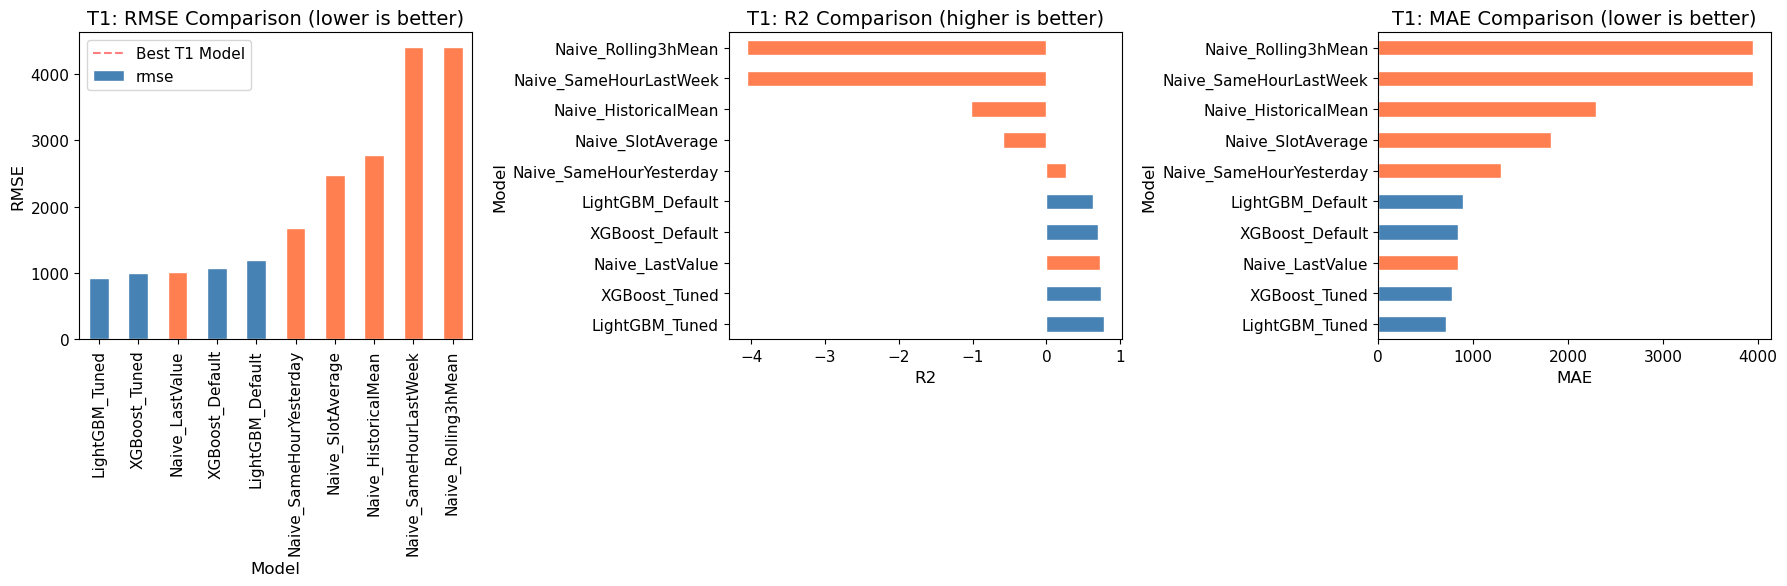

In [11]:
t1_all_results = {}

for name, result in t1_baselines.items():
    t1_all_results[name] = result['val_metrics']


t1_all_results['XGBoost_Default'] = t1_xgb_val
t1_all_results['XGBoost_Tuned'] = t1_xgb_tuned_val
t1_all_results['LightGBM_Default'] = t1_lgb_val
t1_all_results['LightGBM_Tuned'] = t1_lgb_tuned_val

t1_comparison = format_metrics_table(t1_all_results)
t1_comparison = t1_comparison.sort_values('rmse')

print(t1_comparison[['rmse', 'mae', 'r2', 'mape']].to_string())

# Best model
best_t1_name = t1_comparison['rmse'].idxmin()
best_t1_rmse = t1_comparison['rmse'].min()
print(f"\n Best T1 model: {best_t1_name} (RMSE: {best_t1_rmse:.2f})")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RMSE Comparison
ax = axes[0]
colors = ['coral' if 'Naive' in n else 'steelblue' for n in t1_comparison.index]
t1_comparison['rmse'].plot(kind = 'bar', ax = ax, color = colors, edgecolor = 'white')
ax.set_title('T1: RMSE Comparison (lower is better)')
ax.set_ylabel('RMSE')
ax.axvline(best_t1_rmse, color = 'red', linestyle = '--', alpha = 0.5, label = 'Best T1 Model')
ax.legend()

# R2 Comparison
ax = axes[1]
t1_comparison["r2"].plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("T1: R2 Comparison (higher is better)")
ax.set_xlabel("R2")

# MAE Comparison
ax = axes[2]
t1_comparison["mae"].plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("T1: MAE Comparison (lower is better)")
ax.set_xlabel("MAE")

plt.tight_layout()
plt.show()

#### T1: Feature Importance

Top 20 features
             feature  importance
   slot_avg_leakfree         558
            slot_avg         497
              lag_1h         491
        avg_distance         464
   demand_vs_24h_avg         425
             lag_48h         421
             lag_24h         413
            slot_std         408
    avg_duration_sec         397
      wind_speed_kmh         396
             avg_tip         359
              lag_2h         333
         roll_6h_std         332
vs_slot_avg_leakfree         330
   demand_change_24h         323
            avg_fare         298
         roll_3h_std         298
     unique_h3_cells         297
    demand_change_1h         286
          shared_pct         283


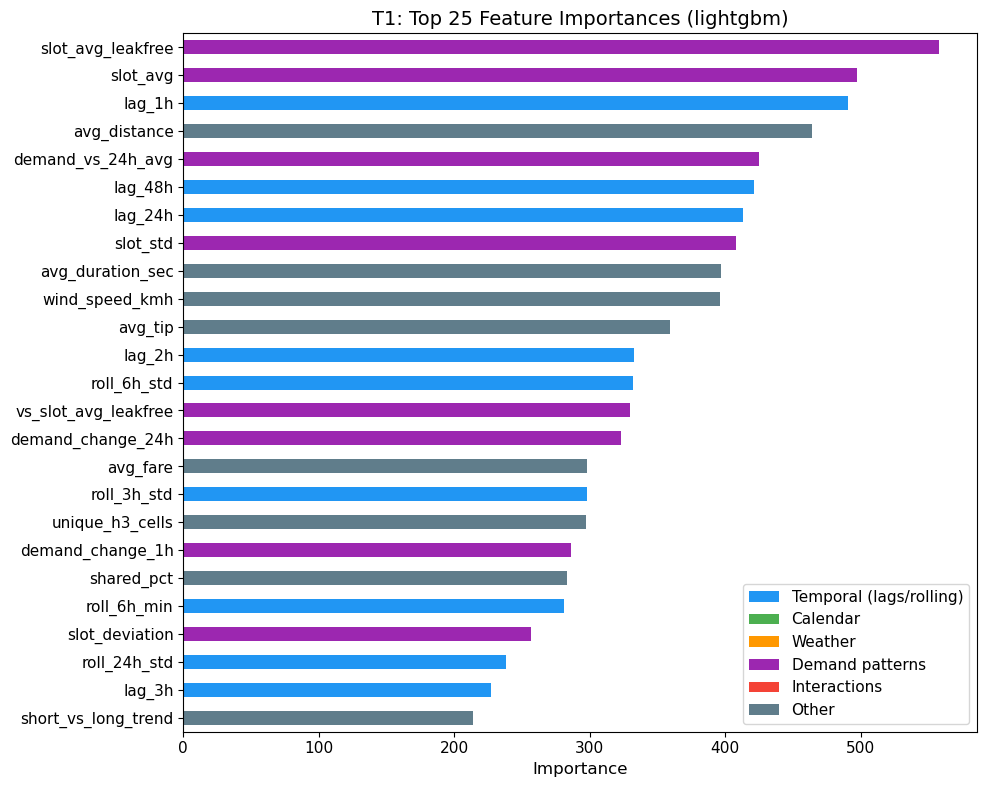

PosixPath('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/models/best/T1/lightgbm')

In [12]:
# Best tuned model
if "XGBoost" in best_t1_name:
    best_t1_model = t1_xgb_tuned
    best_t1_model_type = "xgboost"
    best_t1_params = t1_xgb_best_params
else:
    best_t1_model = t1_lgb_tuned
    best_t1_model_type = 'lightgbm'
    best_t1_params = t1_lgb_best_params


fi = best_t1_model.feature_importances_
feature_names = list(X_train_t1.columns)
fi_df = pd.DataFrame({'feature': feature_names, 'importance': fi}).sort_values('importance', ascending=False)

print("Top 20 features")
print(fi_df.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize = (10, 8))
top_n = min(25, len(fi_df))
fi_top = fi_df.head(top_n).sort_values('importance')

def get_feature_color(fname):
    if "lag" in fname or "roll" in fname:
        return "#2196F3"  # Blue - temporal
    elif "hour" in fname or "dow" in fname or "day" in fname or "week" in fname:
        return "#4CAF50"  # Green - calendar
    elif "weather" in fname or "temp" in fname or "rain" in fname or "snow" in fname:
        return "#FF9800"  # Orange - weather
    elif "slot" in fname or "demand" in fname:
        return "#9C27B0"  # Purple - demand patterns
    elif "commute" in fname or "party" in fname or "business" in fname:
        return "#F44336"  # Red - interaction
    else:
        return "#607D8B"  # Gray - other
    

colors = [get_feature_color(f) for f in fi_top["feature"]]
fi_top.plot(x="feature", y="importance", kind="barh", ax=ax, color=colors, legend=False)
ax.set_title(f"T1: Top {top_n} Feature Importances ({best_t1_model_type})")
ax.set_xlabel("Importance")
ax.set_ylabel("")

# Legend
legend_elements = [
    Patch(facecolor="#2196F3", label="Temporal (lags/rolling)"),
    Patch(facecolor="#4CAF50", label="Calendar"),
    Patch(facecolor="#FF9800", label="Weather"),
    Patch(facecolor="#9C27B0", label="Demand patterns"),
    Patch(facecolor="#F44336", label="Interactions"),
    Patch(facecolor="#607D8B", label="Other"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

save_best_model(best_t1_model, "T1", best_t1_model_type, t1_all_results[best_t1_name], feature_names, best_t1_params)


#### T1: Test Set Evaluation

Test metrics:
MAE: 703.1578
RMSE: 1606.8731
MAPE: 8.9485
SMAPE: 9.4052
R2: 0.7943
MEDIAN_AE: 291.8584


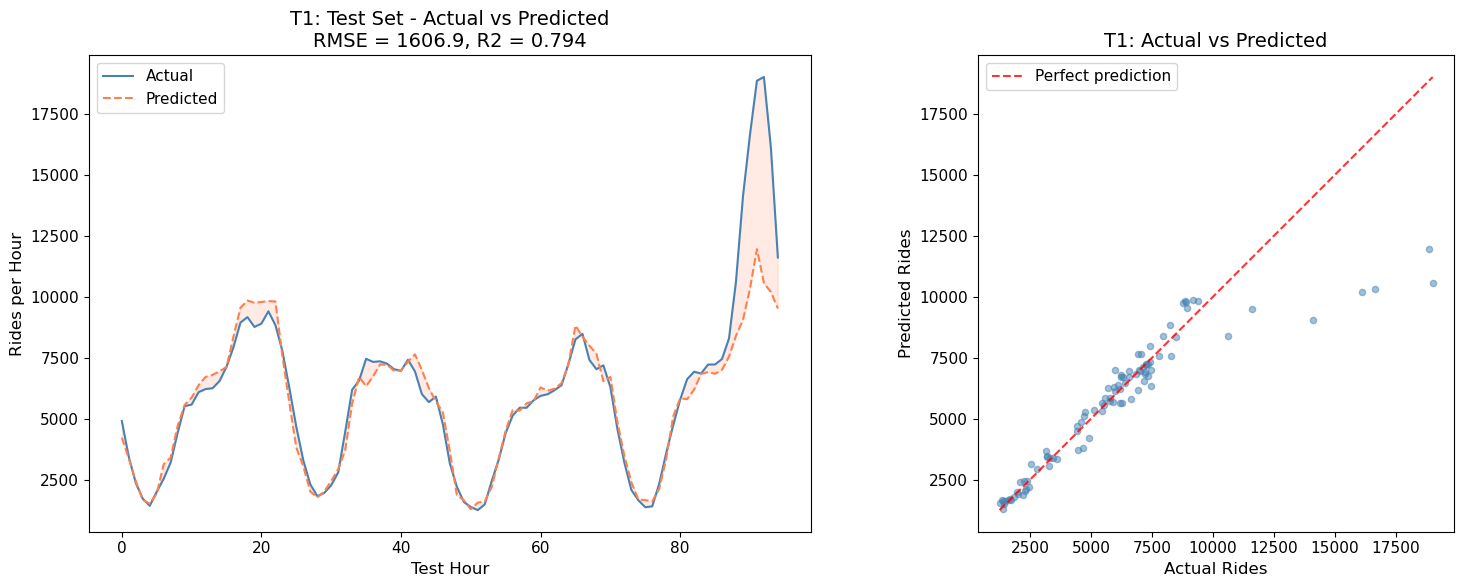

In [13]:
t1_test_preds = best_t1_model.predict(X_test_t1)
t1_test_metrics = compute_metrics(y_test_t1.values, t1_test_preds, 'regression')

print('Test metrics:')
for k, v in t1_test_metrics.items():
    print(f"{k.upper()}: {v:.4f}")

# Actual vs predicted plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
test_index = X_test_t1.index if hasattr(X_test_t1, 'index') else range(len(y_test_t1))

if hasattr(y_test_t1, 'index'):
    plot_idx = y_test_t1.index
else:
    plot_idx = range(len(y_test_t1))

ax.plot(range(len(y_test_t1)), y_test_t1.values, label = 'Actual', color = 'steelblue', linewidth = 1.5)
ax.plot(range(len(t1_test_preds)), t1_test_preds, label = 'Predicted', color = 'coral', linewidth = 1.5, linestyle = '--')
ax.set_title(f'T1: Test Set - Actual vs Predicted\nRMSE = {t1_test_metrics['rmse']:.1f}, R2 = {t1_test_metrics['r2']:.3f}')
ax.set_xlabel('Test Hour')
ax.set_ylabel('Rides per Hour')
ax.legend()
ax.fill_between(range(len(y_test_t1)), y_test_t1.values, t1_test_preds, alpha = 0.15, color = 'coral')

ax = axes[1]
ax.scatter(y_test_t1.values, t1_test_preds, alpha = 0.5, s = 20, color = 'steelblue')
lims = [min(y_test_t1.min(), t1_test_preds.min()), max(y_test_t1.max(), t1_test_preds.max())]
ax.plot(lims, lims, 'r--', alpha = 0.8, label = 'Perfect prediction')
ax.set_title('T1: Actual vs Predicted')
ax.set_xlabel('Actual Rides')
ax.set_ylabel('Predicted Rides')
ax.legend()
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

#### T4: Surge Detection (Classification)

In [14]:
print(f"is_surge distribution:\n{df_city['is_surge'].value_counts()}")
print(f"Surge rate: {df_city['is_surge'].mean():.2%}")

# top 20% of demand
SURGE_PERCENTILE = 80
surge_threshold = df_city["trip_count"].quantile(SURGE_PERCENTILE / 100)
df_city["is_surge"] = (df_city["trip_count"] > surge_threshold).astype(int)

print(f"Threshold: trip_count > {surge_threshold:.0f} (P{SURGE_PERCENTILE})")
print(f"is_surge distribution:\n{df_city['is_surge'].value_counts()}")
print(f"Surge rate: {df_city['is_surge'].mean():.2%}")

train_city, val_city, test_city = temporal_split_citywide(df_city)

print("\nSurges per split:")
for name, subset in [("Train", train_city), ("Val", val_city), ("Test", test_city)]:
    n_surge = subset["is_surge"].sum()
    print(f"  {name}: {n_surge}/{len(subset)} surges ({n_surge/len(subset):.1%})")

is_surge distribution:
is_surge
0    735
1      9
Name: count, dtype: int64
Surge rate: 1.21%
Threshold: trip_count > 7453 (P80)
is_surge distribution:
is_surge
0    595
1    149
Name: count, dtype: int64
Surge rate: 20.03%
18:31:37 │ INFO     │ data.loader │ Temporal split (citywide):
18:31:37 │ INFO     │ data.loader │   Train: 528 rows
18:31:37 │ INFO     │ data.loader │   Val:   120 rows
18:31:37 │ INFO     │ data.loader │   Test:  96 rows
18:31:37 │ INFO     │ data.loader │   Train: 2024-12-01 00:00:00 to 2024-12-22 23:00:00
18:31:37 │ INFO     │ data.loader │   Val: 2024-12-23 00:00:00 to 2024-12-27 23:00:00
18:31:37 │ INFO     │ data.loader │   Test: 2024-12-28 00:00:00 to 2024-12-31 23:00:00

Surges per split:
  Train: 125/528 surges (23.7%)
  Val: 5/120 surges (4.2%)
  Test: 19/96 surges (19.8%)


In [15]:
t4_config = TARGETS['T4']

selected_features_t4 = select_features(train_city, all_numeric_cols, variance_threshold=0.0, correlation_threshold=0.95)

exclude_from_features = {'is_surge', 'target_1h', 'reposition_signal', 'trip_count'}
selected_features_t4 = [f for f in selected_features_t4 if f not in exclude_from_features]
print(f'T4 features: {len(selected_features_t4)}')

X_train_t4, y_train_t4 = prepare_xy(train_city, t4_config.target_column, selected_features_t4)
X_val_t4, y_val_t4 = prepare_xy(val_city, t4_config.target_column, selected_features_t4)
X_test_t4, y_test_t4 = prepare_xy(test_city, t4_config.target_column, selected_features_t4)

# Class balance
for name, y in [('Train', y_train_t4), ('Val', y_val_t4), ('Test', y_test_t4)]:
    if len(y) > 0:
        pos_rate = y.mean()
        print(f"{name}: {len(y)} samples, {pos_rate:.1%} surge, {1-pos_rate:.1%} normal")

n_neg = (y_train_t4 == 0).sum()
n_pos = (y_train_t4 == 1).sum()
scale_pos_weight_t4 = n_neg / max(n_pos, 1)
print(f"\nscale_pos_weight: {scale_pos_weight_t4:.2f}")


18:31:37 │ INFO     │ features.build │ Removing 11 highly correlated features
T4 features: 58
18:31:37 │ INFO     │ data.loader │ Filling NaN in 20 feature columns with 0
Train: 528 samples, 23.7% surge, 76.3% normal
Val: 120 samples, 4.2% surge, 95.8% normal
Test: 96 samples, 19.8% surge, 80.2% normal

scale_pos_weight: 3.22


#### T4: Baselines

In [16]:
t4_baselines = run_classification_baselines(X_train_t4, y_train_t4.values, X_val_t4, y_val_t4.values, X_test_t4, y_test_t4.values, target_type = 'surge')

t4_baseline_val = {name: result['val_metrics'] for name, result in t4_baselines.items()}
t4_baseline_df = format_metrics_table(t4_baseline_val)
print(t4_baseline_df[["accuracy", "precision", "recall", "f1"]].to_string())

18:31:37 │ INFO     │ models.baselines │ ============================================================
18:31:37 │ INFO     │ models.baselines │ Running classification baselines
18:31:37 │ INFO     │ models.baselines │ ============================================================
18:31:37 │ INFO     │ models.baselines │ 
 Naive_AlwaysMajority
18:31:37 │ INFO     │ models.evaluation │ Naive_AlwaysMajority - val metrics: {'accuracy': 0.9583, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': 0.5, 'true_positivies': 0, 'true_negatives': 115, 'false_positives': 0, 'false_negatives': 5}
18:31:37 │ INFO     │ models.evaluation │ accuracy: 0.9583
18:31:37 │ INFO     │ models.evaluation │ precision: 0.0000
18:31:37 │ INFO     │ models.evaluation │ recall: 0.0000
18:31:37 │ INFO     │ models.evaluation │ f1: 0.0000
18:31:37 │ INFO     │ models.evaluation │ roc_auc: 0.5000
18:31:37 │ INFO     │ models.evaluation │ true_positivies: 0
18:31:37 │ INFO     │ models.evaluation │ true_negatives: 115


#### T4: XGBoost & LightGBM (Default + Tuned)

In [17]:
# Default XGBoost
t4_xgb_model, t4_xgb_val, t4_xgb_train = train_xgboost(X_train_t4, y_train_t4.values, X_val_t4, y_val_t4.values, task_type = 'classification', scale_pos_weight = scale_pos_weight_t4, experiment_name = t4_config.mlflow_experiment, run_name = 'T4_xgb_default', feature_names = list(X_train_t4.columns))

# Default LightGBM
t4_lgb_model, t4_lgb_val, t4_lgb_train = train_lightgbm(X_train_t4, y_train_t4.values, X_val_t4, y_val_t4.values, task_type = 'classification', scale_pos_weight = scale_pos_weight_t4, experiment_name = t4_config.mlflow_experiment, run_name = 'T4_lgb_default', feature_names = list(X_train_t4.columns))

# Tune XGBoost
t4_xgb_study, t4_xgb_best_params = run_optuna_study(xgboost_classification_objective, X_train_t4.values, y_train_t4.values, X_val_t4.values, y_val_t4.values, n_trials = 50, direction = 'maximize', study_name = 'T4_xgb_tuning', scale_pos_weight = scale_pos_weight_t4)
t4_xgb_tuned, t4_xgb_tuned_val, _ = train_tuned_model(X_train_t4,y_train_t4.values, X_val_t4, y_val_t4.values, task_type = 'classification', model_type = 'xgboost', best_params = t4_xgb_best_params, scale_pos_weight = scale_pos_weight_t4, experiment_name = t4_config.mlflow_experiment, run_name = 'T4_xgb_tuned', feature_names = list(X_train_t4.columns))

# Tune LightGBM
t4_lgb_study, t4_lgb_best_params = run_optuna_study(lightgbm_classification_objective, X_train_t4.values, y_train_t4.values, X_val_t4.values, y_val_t4.values, n_trials = 50, direction = 'maximize', study_name = 'T4_lgb_tuning', scale_pos_weight = scale_pos_weight_t4)
t4_lgb_tuned, t4_lgb_tuned_val, _ = train_tuned_model(X_train_t4, y_train_t4.values, X_val_t4, y_val_t4.values, task_type = 'classification', model_type = 'lightgbm', best_params = t4_lgb_best_params, scale_pos_weight = scale_pos_weight_t4, experiment_name = t4_config.mlflow_experiment, run_name = 'T4_lgb_tuned', feature_names = list(X_train_t4.columns))

18:31:37 │ INFO     │ models.evaluation │ T4_xgb_default - train metrics: {'accuracy': 0.9981, 'precision': 0.9921, 'recall': 0.996, 'f1': 0.996, 'roc_auc': 1.0, 'true_positivies': 125, 'true_negatives': 402, 'false_positives': 1, 'false_negatives': 0}
18:31:37 │ INFO     │ models.evaluation │ accuracy: 0.9981
18:31:37 │ INFO     │ models.evaluation │ precision: 0.9921
18:31:37 │ INFO     │ models.evaluation │ recall: 0.9960
18:31:37 │ INFO     │ models.evaluation │ f1: 0.9960
18:31:37 │ INFO     │ models.evaluation │ roc_auc: 1.0000
18:31:37 │ INFO     │ models.evaluation │ true_positivies: 125
18:31:37 │ INFO     │ models.evaluation │ true_negatives: 402
18:31:37 │ INFO     │ models.evaluation │ false_positives: 1
18:31:37 │ INFO     │ models.evaluation │ false_negatives: 0
18:31:37 │ INFO     │ models.evaluation │ T4_xgb_default - val metrics: {'accuracy': 0.9, 'precision': 0.2941, 'recall': 0.4545, 'f1': 0.4545, 'roc_auc': 0.9965, 'true_positivies': 5, 'true_negatives': 103, 'false

2026/03/11 18:31:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 18:31:38 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


18:31:41 │ INFO     │ models.tuner │ Starting optuna study: T4_xgb_tuning (50 trials, direction=maximize)


Best trial: 43. Best value: 0.714286: 100%|██████████| 50/50 [00:15<00:00,  3.22it/s]

18:31:56 │ INFO     │ models.tuner │ Best trial: 0.7142857142857143 with params: {'n_estimators': 211, 'max_depth': 10, 'learning_rate': 0.033120618056489054, 'min_child_weight': 1, 'subsample': 0.8914198654626228, 'colsample_bytree': 0.42314452420336385, 'reg_alpha': 0.17393356652412492, 'reg_lambda': 0.7157188345803132, 'gamma': 0.00011009601401046104}
18:31:56 │ INFO     │ models.tuner │ Best params: {'n_estimators': 211, 'max_depth': 10, 'learning_rate': 0.033120618056489054, 'min_child_weight': 1, 'subsample': 0.8914198654626228, 'colsample_bytree': 0.42314452420336385, 'reg_alpha': 0.17393356652412492, 'reg_lambda': 0.7157188345803132, 'gamma': 0.00011009601401046104}


18:31:56 │ INFO     │ models.evaluation │ T4_xgb_tuned - train metrics: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'roc_auc': 1.0, 'true_positivies': 125, 'true_negatives': 403, 'false_positives': 0, 'false_negatives': 0}
18:31:56 │ INFO     │ models.evaluation │ accuracy: 1.0000
18:31:56 │ INFO     │ models.evaluation │ precision: 1.0000
18:31:56 │ INFO     │ models.evaluation │ recall: 1.0000
18:31:56 │ INFO     │ models.evaluation │ f1: 1.0000
18:31:56 │ INFO     │ models.evaluation │ roc_auc: 1.0000
18:31:56 │ INFO     │ models.evaluation │ true_positivies: 125
18:31:56 │ INFO     │ models.evaluation │ true_negatives: 403
18:31:56 │ INFO     │ models.evaluation │ false_positives: 0
18:31:56 │ INFO     │ models.evaluation │ false_negatives: 0
18:31:56 │ INFO     │ models.evaluation │ T4_xgb_tuned - val metrics: {'accuracy': 0.9667, 'precision': 0.5556, 'recall': 0.7143, 'f1': 0.7143, 'roc_auc': 1.0, 'true_positivies': 5, 'true_negatives': 111, 'false_positives': 4

Best trial: 17. Best value: 1: 100%|██████████| 50/50 [00:21<00:00,  2.38it/s]      

18:32:18 │ INFO     │ models.tuner │ Best trial: 1.0 with params: {'n_estimators': 462, 'max_depth': 8, 'learning_rate': 0.04300171938641868, 'num_leaves': 66, 'min_child_samples': 11, 'subsample': 0.8256450600312465, 'colsample_bytree': 0.5242378146805416, 'reg_alpha': 2.043442636576265e-06, 'reg_lambda': 0.0020222602671843225}
18:32:18 │ INFO     │ models.tuner │ Best params: {'n_estimators': 462, 'max_depth': 8, 'learning_rate': 0.04300171938641868, 'num_leaves': 66, 'min_child_samples': 11, 'subsample': 0.8256450600312465, 'colsample_bytree': 0.5242378146805416, 'reg_alpha': 2.043442636576265e-06, 'reg_lambda': 0.0020222602671843225}



2026/03/11 18:32:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 18:32:19 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


#### T4: Comparison & Test Evaluation

In [18]:
t4_all_results = {}
for name, result in t4_baselines.items():
    t4_all_results[name] = result['val_metrics']
t4_all_results["XGBoost_Default"] = t4_xgb_val
t4_all_results["LightGBM_Default"] = t4_lgb_val
t4_all_results["XGBoost_Tuned"] = t4_xgb_tuned_val
t4_all_results["LightGBM_Tuned"] = t4_lgb_tuned_val

t4_comparison = format_metrics_table(t4_all_results)
display_cols = ["f1", "precision", "recall", "accuracy"]
available_cols = [c for c in display_cols if c in t4_comparison.columns]
t4_comparison_sorted = t4_comparison.sort_values("f1", ascending=False)

print(t4_comparison_sorted[available_cols].to_string())

best_t4_name = t4_comparison_sorted["f1"].idxmax()
print(f"\nBest T4 Model: {best_t4_name} (F1: {t4_comparison_sorted['f1'].max():.4f})")

if "XGBoost_Tuned" == best_t4_name:
    best_t4_model = t4_xgb_tuned
    best_t4_params = t4_xgb_best_params
    best_t4_type = "xgboost"
elif "LightGBM_Tuned" == best_t4_name:
    best_t4_model = t4_lgb_tuned
    best_t4_params = t4_lgb_best_params
    best_t4_type = "lightgbm"
elif "XGBoost_Default" == best_t4_name:
    best_t4_model = t4_xgb_model
    best_t4_params = {}
    best_t4_type = "xgboost"
else:
    best_t4_model = t4_lgb_model
    best_t4_params = {}
    best_t4_type = "lightgbm"

t4_test_preds = best_t4_model.predict(X_test_t4)
t4_test_probs = best_t4_model.predict_proba(X_test_t4)[:, 1] if hasattr(best_t4_model, "predict_proba") else None
t4_test_metrics = compute_metrics(y_test_t4.values, t4_test_preds, "classification", t4_test_probs)

print(f"\nTest Metrics:")
for k, v in t4_test_metrics.items():
    print(f"{k}: {v}")

save_best_model(best_t4_model, "T4", best_t4_type, t4_all_results[best_t4_name], list(X_train_t4.columns), best_t4_params)

                                              f1  precision  recall  accuracy
Model                                                                        
LightGBM_Tuned                            1.0000     1.0000  1.0000    1.0000
XGBoost_Tuned                             0.7143     0.5556  0.7143    0.9667
LightGBM_Default                          0.6667     0.5000  0.6667    0.9583
XGBoost_Default                           0.4545     0.2941  0.4545    0.9000
Naive_Threshold(demand_vs_24h_avg > 1.5)  0.4000     0.2500  0.4000    0.8750
Naive_ClassRate                           0.0513     0.0294  0.0513    0.6917
Naive_AlwaysMajority                      0.0000     0.0000  0.0000    0.9583

Best T4 Model: LightGBM_Tuned (F1: 1.0000)

Test Metrics:
accuracy: 0.9583
precision: 0.8947
recall: 0.8947
f1: 0.8947
roc_auc: 0.9911
true_positivies: 17
true_negatives: 75
false_positives: 2
false_negatives: 2


PosixPath('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/models/best/T4/lightgbm')

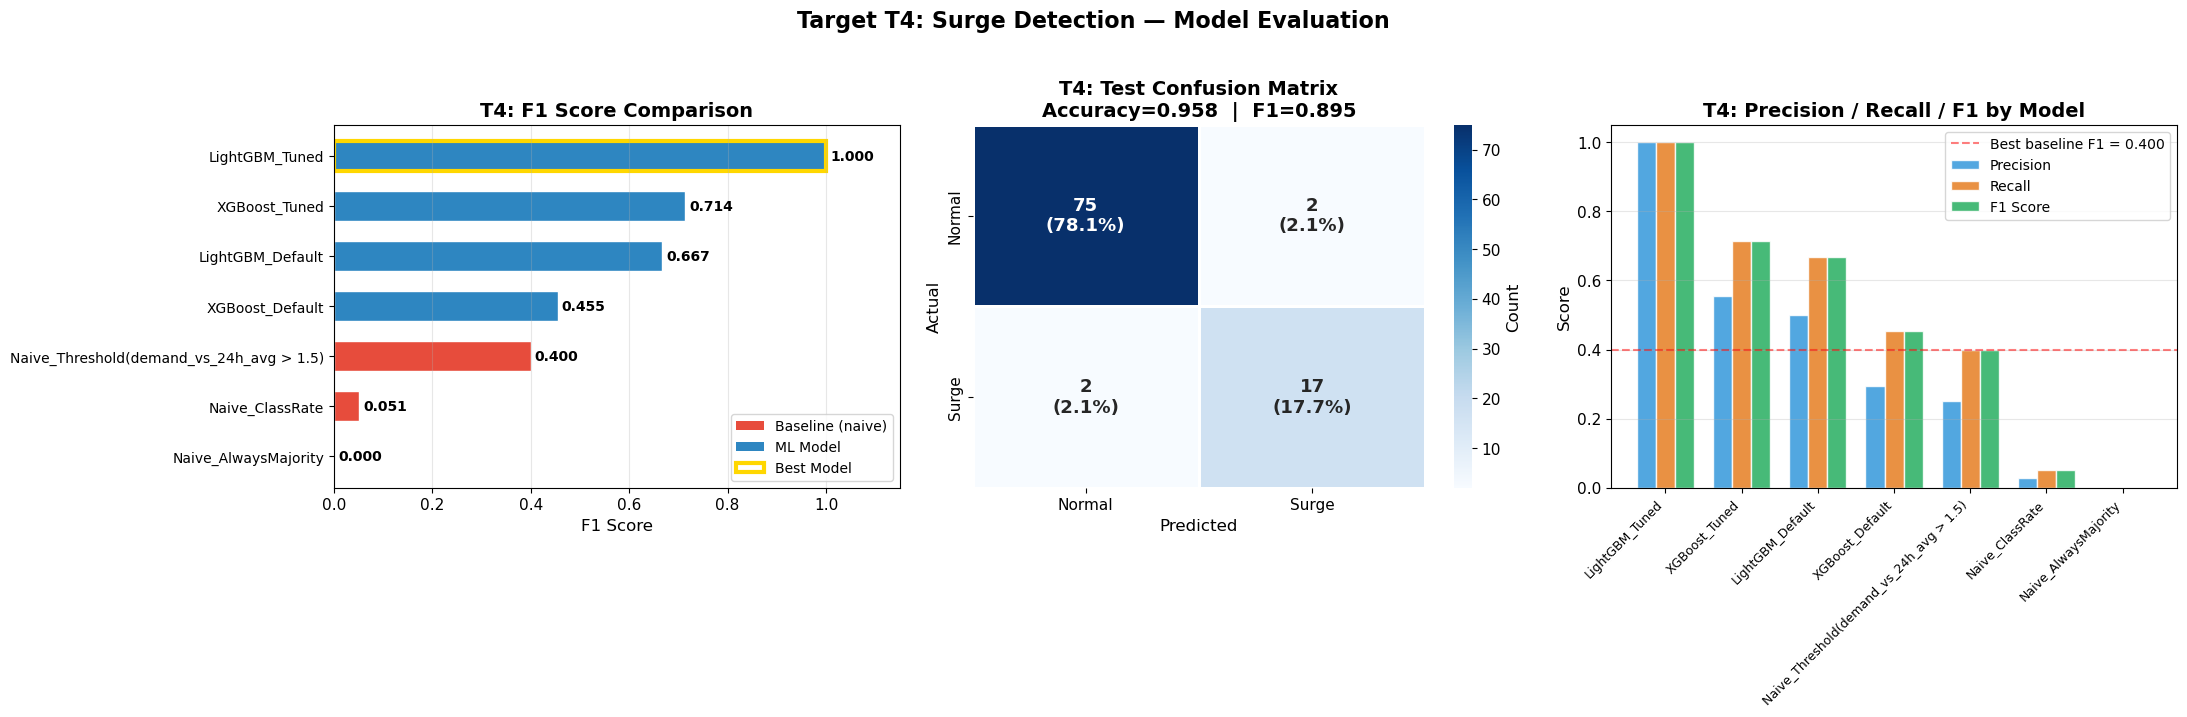

T4 DETAILED RESULTS

Best Model: LightGBM_Tuned
Test Set Metrics:
            accuracy: 0.9583
           precision: 0.8947
              recall: 0.8947
                  f1: 0.8947
             roc_auc: 0.9911
     true_positivies: 17
      true_negatives: 75
     false_positives: 2
     false_negatives: 2

Confusion Matrix:
True Negatives:     75  (correctly predicted Normal)
False Positives:     2  (predicted Surge, was Normal)
False Negatives:     2  (predicted Normal, was Surge)
True Positives:     17  (correctly predicted Surge)


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# F1 score
ax = axes[0]

f1_scores = t4_comparison_sorted["f1"].dropna().sort_values(ascending=True)
colors = ["#E74C3C" if "Naive" in n else "#2E86C1" for n in f1_scores.index]

bars = ax.barh(range(len(f1_scores)), f1_scores.values, color=colors, 
               edgecolor="white", height=0.6)

ax.set_yticks(range(len(f1_scores)))
ax.set_yticklabels(f1_scores.index, fontsize=10)
ax.set_title("T4: F1 Score Comparison", fontsize=14, fontweight="bold")
ax.set_xlabel("F1 Score", fontsize=12)

for i, val in enumerate(f1_scores.values):
    ax.text(val + 0.008, i, f"{val:.3f}", va="center", fontsize=10, fontweight="bold")

# Best model highlight
best_idx = f1_scores.values.argmax()
bars[best_idx].set_edgecolor("gold")
bars[best_idx].set_linewidth(3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#E74C3C", label="Baseline (naive)"),
    Patch(facecolor="#2E86C1", label="ML Model"),
    Patch(facecolor="white", edgecolor="gold", linewidth=3, label="Best Model"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10)

ax.set_xlim(0, max(f1_scores.values) * 1.15)
ax.grid(axis="x", alpha=0.3)

# Confusion Matrix
ax = axes[1]

cm = confusion_matrix(y_test_t4.values, t4_test_preds, labels=[0, 1])

cm_pct = cm.astype(float) / cm.sum() * 100
annot = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" 
                   for j in range(2)] for i in range(2)])

sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", ax=ax, xticklabels=["Normal", "Surge"], yticklabels=["Normal", "Surge"], cbar_kws={"label": "Count"}, linewidths=2, linecolor="white", annot_kws={"fontsize": 13, "fontweight": "bold"})

ax.set_title(f"T4: Test Confusion Matrix\n"
             f"Accuracy={t4_test_metrics['accuracy']:.3f}  |  "
             f"F1={t4_test_metrics['f1']:.3f}", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)

# Precision, Recall, F1 by Model
ax = axes[2]

models = t4_comparison_sorted.index.tolist()
precision_vals = t4_comparison_sorted["precision"].values
recall_vals = t4_comparison_sorted["recall"].values
f1_vals = t4_comparison_sorted["f1"].values

x = np.arange(len(models))
width = 0.25

bars1 = ax.bar(x - width, precision_vals, width, label="Precision", color="#3498DB", edgecolor="white", alpha=0.85)
bars2 = ax.bar(x, recall_vals, width, label="Recall", color="#E67E22", edgecolor="white", alpha=0.85)
bars3 = ax.bar(x + width, f1_vals, width, label="F1 Score", color="#27AE60", edgecolor="white", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right", fontsize=9)
ax.set_title("T4: Precision / Recall / F1 by Model", fontsize=14, fontweight="bold")
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right", fontsize=10)
ax.grid(axis="y", alpha=0.3)

# Horizontal line at best baseline F1
best_baseline_f1 = max(
    [t4_baselines[name]["val_metrics"]["f1"] for name in t4_baselines], default=0
)
if best_baseline_f1 > 0:
    ax.axhline(best_baseline_f1, color="red", linestyle="--", alpha=0.5, label=f"Best baseline F1 = {best_baseline_f1:.3f}")
    ax.legend(loc="upper right", fontsize=10)

plt.suptitle("Target T4: Surge Detection — Model Evaluation", 
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("T4 DETAILED RESULTS")
print(f"\nBest Model: {t4_comparison_sorted['f1'].idxmax()}")
print(f"Test Set Metrics:")
for k, v in t4_test_metrics.items():
    print(f"{k:>20s}: {v}")
print(f"\nConfusion Matrix:")
print(f"True Negatives:  {cm[0,0]:>5d}  (correctly predicted Normal)")
print(f"False Positives: {cm[0,1]:>5d}  (predicted Surge, was Normal)")
print(f"False Negatives: {cm[1,0]:>5d}  (predicted Normal, was Surge)")
print(f"True Positives:  {cm[1,1]:>5d}  (correctly predicted Surge)")

#### T3: H3 Cell Demand (Regression)

In [20]:
df_h3 = load_h3_data(sample_frac=None)
print(f"H3 data shape: {df_h3.shape}")

train_h3, val_h3, test_h3 = temporal_split_h3(df_h3)

t3_config = TARGETS['T3']
h3_feature_cols = get_feature_columns('T3')

selected_features_t3 = select_features(train_h3, h3_feature_cols, variance_threshold = 0.0, correlation_threshold = 0.95)

# Remove target-related features
exclude_h3 = {'target_1h', 'trip_count', 'is_surge', 'reposition_signal'}
selected_features_t3 = [f for f in selected_features_t3 if f not in exclude_h3]

X_train_t3, y_train_t3 = prepare_xy(train_h3, t3_config.target_column, selected_features_t3)
X_val_t3, y_val_t3 = prepare_xy(val_h3, t3_config.target_column, selected_features_t3)
X_test_t3, y_test_t3 = prepare_xy(test_h3, t3_config.target_column, selected_features_t3)

print(f"Train: {X_train_t3.shape}")
print(f"Val:   {X_val_t3.shape}")
print(f"Test:  {X_test_t3.shape}")
print(f"y_train range: [{y_train_t3.min()}, {y_train_t3.max()}], mean={y_train_t3.mean():.2f}")


18:32:22 │ INFO     │ data.loader │ Loading H3 data from /Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/processed/chirde.h3_hourly_comp.parquet
18:32:23 │ INFO     │ data.loader │   Raw columns: ['hour_bucket', 'h3_index', 'trip_count', 'avg_fare', 'avg_duration_sec', 'avg_distance', 'shared_pct', 'hour', 'day_of_week', 'day_of_month']... (95 total)
18:32:23 │ INFO     │ data.loader │   Datetime column: 'hour_bucket'
18:32:23 │ INFO     │ data.loader │ Shape: (403248, 95)
H3 data shape: (403248, 95)
18:32:25 │ INFO     │ features.build │ Removing 11 highly correlated features
18:32:25 │ INFO     │ data.loader │ Filling NaN in 9 feature columns with 0
18:32:25 │ INFO     │ data.loader │ Filling NaN in 1 feature columns with 0
18:32:25 │ INFO     │ data.loader │   Dropped 542 rows with NaN target
18:32:25 │ INFO     │ data.loader │ Filling NaN in 1 feature columns with 0
Train: (286176, 55)
Val:   (65040, 55)
Test:  (51490, 55)
y_train range: [0.0, 814.0], mean=10.92


#### T3: Baselines

In [21]:
t3_baselines = run_regression_baselines(X_train_t3, y_train_t3.values, X_val_t3, y_val_t3.values, X_test_t3, y_test_t3.values)

t3_baseline_val = {name: result['val_metrics'] for name, result in t3_baselines.items()}
t3_baseline_df = format_metrics_table(t3_baseline_val)
print(t3_baseline_df.to_string())

best_baseline_rmse_t3 = t3_baseline_df["rmse"].min()
print(f"\nBest baseline RMSE: {best_baseline_rmse_t3:.4f}")

18:32:25 │ INFO     │ models.baselines │ ============================================================
18:32:25 │ INFO     │ models.baselines │ Running regression baselines
18:32:25 │ INFO     │ models.baselines │ ============================================================
18:32:25 │ INFO     │ models.baselines │ 
 Naive_LastValue
18:32:25 │ INFO     │ models.evaluation │ Naive_LastValue - val metrics: {'mae': 7.2726, 'rmse': np.float64(22.8705), 'mape': np.float64(100.0), 'smape': np.float64(200.0), 'r2': -0.1125, 'median_ae': np.float64(1.0)}
18:32:25 │ INFO     │ models.evaluation │ mae: 7.2726
18:32:25 │ INFO     │ models.evaluation │ rmse: 22.8705
18:32:25 │ INFO     │ models.evaluation │ mape: 100.0000
18:32:25 │ INFO     │ models.evaluation │ smape: 200.0000
18:32:25 │ INFO     │ models.evaluation │ r2: -0.1125
18:32:25 │ INFO     │ models.evaluation │ median_ae: 1.0000
18:32:25 │ INFO     │ models.baselines │ 
 Naive_SameHourYesterday
18:32:25 │ INFO     │ models.evaluation │ N

#### T3: XGBoost & LightGBM + Tuning

In [23]:
# Default XGBoost
t3_xgb_model, t3_xgb_val, _ = train_xgboost(X_train_t3, y_train_t3.values, X_val_t3, y_val_t3.values, task_type = 'regression', experiment_name = t3_config.mlflow_experiment, run_name = 'T3_xgb_default', feature_names = list(X_train_t3.columns))

# Default LightGBM
t3_lgb_model, t3_lgb_val, _ = train_lightgbm(X_train_t3, y_train_t3.values, X_val_t3, y_val_t3.values, task_type = 'regression', experiment_name = t3_config.mlflow_experiment, run_name = 'T3_lgb_default', feature_names = list(X_train_t3.columns))

# Optuna tuning for T3
t3_xgb_study, t3_xgb_best_params = run_optuna_study(xgboost_regression_objective, X_train_t3.values, y_train_t3.values, X_val_t3.values, y_val_t3.values, n_trials = 30, direction = 'minimize', study_name = 'T3_xgb_tuning')
t3_xgb_tuned, t3_xgb_tuned_val, _ = train_tuned_model(X_train_t3, y_train_t3.values, X_val_t3, y_val_t3.values, task_type = "regression", model_type = "xgboost", best_params = t3_xgb_best_params, experiment_name = t3_config.mlflow_experiment, run_name = "T3_xgb_tuned", feature_names = list(X_train_t3.columns))
t3_lgb_study, t3_lgb_best_params = run_optuna_study(lightgbm_regression_objective, X_train_t3.values, y_train_t3.values, X_val_t3.values, y_val_t3.values, n_trials = 30, direction = 'minimize', study_name = 'T3_lgb_tuning')
t3_lgb_tuned, t3_lgb_tuned_val, _ = train_tuned_model(X_train_t3, y_train_t3.values, X_val_t3, y_val_t3.values, task_type = 'regression', model_type = 'lightgbm', best_params = t3_lgb_best_params, experiment_name = t3_config.mlflow_experiment, run_name = 'T3_lgb_tuned', feature_names = list(X_train_t3.columns))

19:36:48 │ INFO     │ models.evaluation │ T3_xgb_default - train metrics: {'mae': 2.1873, 'rmse': np.float64(4.2371), 'mape': np.float64(47.4032), 'smape': np.float64(109.285), 'r2': 0.9855, 'median_ae': np.float64(0.9288)}
19:36:48 │ INFO     │ models.evaluation │ mae: 2.1873
19:36:48 │ INFO     │ models.evaluation │ rmse: 4.2371
19:36:48 │ INFO     │ models.evaluation │ mape: 47.4032
19:36:48 │ INFO     │ models.evaluation │ smape: 109.2850
19:36:48 │ INFO     │ models.evaluation │ r2: 0.9855
19:36:48 │ INFO     │ models.evaluation │ median_ae: 0.9288
19:36:48 │ INFO     │ models.evaluation │ T3_xgb_default - val metrics: {'mae': 2.6506, 'rmse': np.float64(7.4643), 'mape': np.float64(67.5744), 'smape': np.float64(122.3568), 'r2': 0.8815, 'median_ae': np.float64(0.9021)}
19:36:48 │ INFO     │ models.evaluation │ mae: 2.6506
19:36:48 │ INFO     │ models.evaluation │ rmse: 7.4643
19:36:48 │ INFO     │ models.evaluation │ mape: 67.5744
19:36:48 │ INFO     │ models.evaluation │ smape: 122

2026/03/11 19:36:48 INFO mlflow.tracking.fluent: Experiment with name 'T3_H3_Demand' does not exist. Creating a new experiment.
2026/03/11 19:36:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 19:36:55 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


19:36:58 │ INFO     │ models.tuner │ Starting optuna study: T3_xgb_tuning (30 trials, direction=minimize)


Best trial: 3. Best value: 6.32457: 100%|██████████| 30/30 [04:53<00:00,  9.78s/it]

19:41:51 │ INFO     │ models.tuner │ Best trial: 6.324574969340686 with params: {'n_estimators': 820, 'max_depth': 7, 'learning_rate': 0.011711509955524094, 'min_child_weight': 7, 'subsample': 0.5852620618436457, 'colsample_bytree': 0.3455361150896957, 'reg_alpha': 3.4671276804481113, 'reg_lambda': 9.23915031962725, 'gamma': 0.10770212765048791}
19:41:51 │ INFO     │ models.tuner │ Best params: {'n_estimators': 820, 'max_depth': 7, 'learning_rate': 0.011711509955524094, 'min_child_weight': 7, 'subsample': 0.5852620618436457, 'colsample_bytree': 0.3455361150896957, 'reg_alpha': 3.4671276804481113, 'reg_lambda': 9.23915031962725, 'gamma': 0.10770212765048791}


19:42:02 │ INFO     │ models.evaluation │ T3_xgb_tuned - train metrics: {'mae': 2.3764, 'rmse': np.float64(5.2664), 'mape': np.float64(48.1205), 'smape': np.float64(109.3602), 'r2': 0.9776, 'median_ae': np.float64(0.9401)}
19:42:02 │ INFO     │ models.evaluation │ mae: 2.3764
19:42:02 │ INFO     │ models.evaluation │ rmse: 5.2664
19:42:02 │ INFO     │ models.evaluation │ mape: 48.1205
19:42:02 │ INFO     │ models.evaluation │ smape: 109.3602
19:42:02 │ INFO     │ models.evaluation │ r2: 0.9776
19:42:02 │ INFO     │ models.evaluation │ median_ae: 0.9401
19:42:02 │ INFO     │ models.evaluation │ T3_xgb_tuned - val metrics: {'mae': 2.5573, 'rmse': np.float64(6.3246), 'mape': np.float64(67.9678), 'smape': np.float64(121.1682), 'r2': 0.9149, 'median_ae': np.float64(0.9508)}
19:42:02 │ INFO     │ models.evaluation │ mae: 2.5573
19:42:02 │ INFO     │ models.evaluation │ rmse: 6.3246
19:42:02 │ INFO     │ models.evaluation │ mape: 67.9678
19:42:02 │ INFO     │ models.evaluation │ smape: 121.16

Best trial: 17. Best value: 6.77564: 100%|██████████| 30/30 [23:51<00:00, 47.70s/it] 

20:05:54 │ INFO     │ models.tuner │ Best trial: 6.775639970628523 with params: {'n_estimators': 1121, 'max_depth': 10, 'learning_rate': 0.0516264606819185, 'num_leaves': 56, 'min_child_samples': 22, 'subsample': 0.7299931044372592, 'colsample_bytree': 0.4713253737600194, 'reg_alpha': 3.4209876534185466e-07, 'reg_lambda': 0.0002866158465898892, 'min_split_gain': 1.0662740048029236e-05}
20:05:54 │ INFO     │ models.tuner │ Best params: {'n_estimators': 1121, 'max_depth': 10, 'learning_rate': 0.0516264606819185, 'num_leaves': 56, 'min_child_samples': 22, 'subsample': 0.7299931044372592, 'colsample_bytree': 0.4713253737600194, 'reg_alpha': 3.4209876534185466e-07, 'reg_lambda': 0.0002866158465898892, 'min_split_gain': 1.0662740048029236e-05}



2026/03/11 20:08:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 20:08:16 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


#### T3 Comparison

                            rmse      mae      r2
Model                                            
XGBoost_Tuned             6.3246   2.5573  0.9149
LightGBM_Tuned            6.7756   2.5423  0.9024
XGBoost_Default           7.4643   2.6506  0.8815
LightGBM_Default          7.8392   2.6786  0.8693
Naive_SameHourYesterday  12.4834   3.7487  0.6686
Naive_SlotAverage        15.3286   4.1299  0.5003
Naive_HistoricalMean     21.9881  12.1057 -0.0283
Naive_LastValue          22.8705   7.2726 -0.1125
Naive_SameHourLastWeek   22.8705   7.2726 -0.1125
Naive_Rolling3hMean      22.8705   7.2726 -0.1125

Best T3 model: XGBoost_Tuned (RMSE: 6.3246)


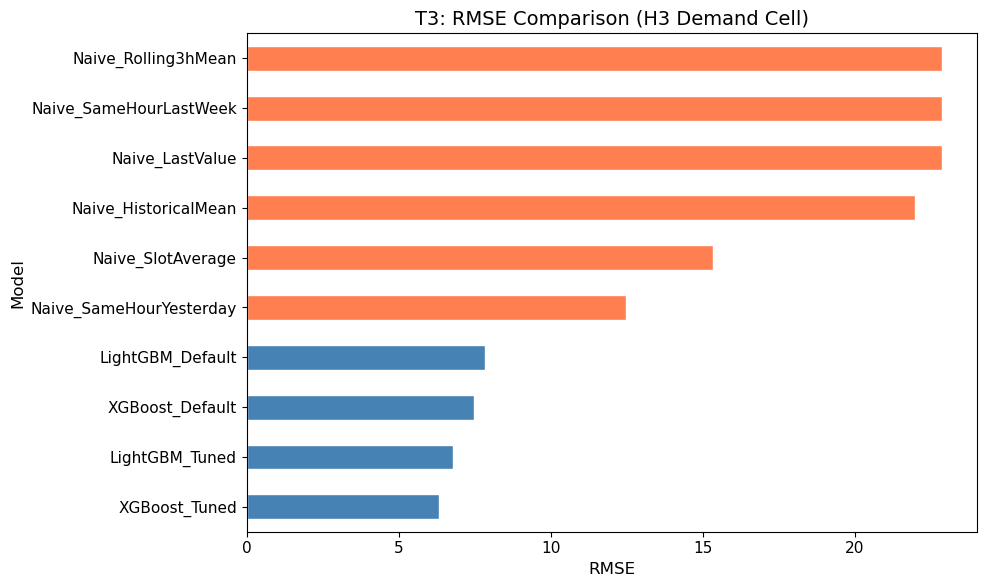

In [24]:
t3_all_results = {}
for name, result in t3_baselines.items():
    t3_all_results[name] = result['val_metrics']
t3_all_results['XGBoost_Default'] = t3_xgb_val
t3_all_results['XGBoost_Tuned'] = t3_xgb_tuned_val
t3_all_results['LightGBM_Default'] = t3_lgb_val
t3_all_results['LightGBM_Tuned'] = t3_lgb_tuned_val

t3_comparison = format_metrics_table(t3_all_results).sort_values('rmse')
print(t3_comparison[['rmse', 'mae', 'r2']].to_string())

best_t3_name = t3_comparison['rmse'].idxmin()
print(f"\nBest T3 model: {best_t3_name} (RMSE: {t3_comparison['rmse'].min():.4f})")

if 'XGBoost_Tuned' == best_t3_name:
    best_t3_model = t3_xgb_tuned
    best_t3_params = t3_xgb_best_params
    best_t3_type = "xgboost"
elif 'LightGBM_Tuned' == best_t3_name:
    best_t3_model = t3_lgb_tuned
    best_t3_params = t3_lgb_best_params
    best_t3_type = "lightgbm"
elif 'XGBoost_Default' == best_t3_name:
    best_t3_model = t3_xgb_model
    best_t3_params = {}
    best_t3_type = "xgboost"
else:    
    best_t3_model = t3_lgb_model
    best_t3_params = {}
    best_t3_type = "lightgbm"

# Test evaluation
t3_test_preds = best_t3_model.predict(X_test_t3)
t3_test_metrics = compute_metrics(y_test_t3.values, t3_test_preds, 'regression')

save_best_model(best_t3_model, 'T3', best_t3_type, t3_all_results[best_t3_name], list(X_train_t3.columns), best_t3_params)

fig, ax = plt.subplots(figsize = (10, 6))
colors = ['coral' if 'Naive' in n else 'steelblue' for n in t3_comparison.index]
t3_comparison['rmse'].plot(kind = 'barh', ax = ax, color = colors, edgecolor = 'white')
ax.set_title('T3: RMSE Comparison (H3 Demand Cell)')
ax.set_xlabel('RMSE')
plt.tight_layout()
plt.show()

#### T2: Repositioning (Classification on H3 Data)

In [30]:
t2_config = TARGETS["T2"]

selected_features_t2 = [f for f in selected_features_t3 if f not in {"reposition_signal", "is_surge", "target_1h", "trip_count"}]

print("Converting reposition_signal to binary")
print(f"Original categories: {train_h3['reposition_signal'].unique()}")
print(f"Original value counts:\n{train_h3['reposition_signal'].value_counts()}\n")

# Binary mapping:
#   1 = "go here" (high demand, drivers should reposition TO this zone)
#   0 = "don't go" (normal/oversupplied, no need to reposition here)
reposition_mapping = {
    "strongly_go_here": 1,
    "go_here": 1,
    "stay": 0,
    "leave": 0,
    "strong_leave": 0,
}

for split_df in [train_h3, val_h3, test_h3]:
    split_df["reposition_signal"] = (
        split_df["reposition_signal"]
        .map(reposition_mapping)
        .astype(float) 
    )
    split_df["reposition_signal"] = split_df["reposition_signal"].fillna(0).astype(int)

print(f"After conversion:")
print(f"dtype: {train_h3['reposition_signal'].dtype}")
print(f"Value counts:\n{train_h3['reposition_signal'].value_counts()}")

X_train_t2, y_train_t2 = prepare_xy(train_h3, t2_config.target_column, selected_features_t2)
X_val_t2, y_val_t2 = prepare_xy(val_h3, t2_config.target_column, selected_features_t2)
X_test_t2, y_test_t2 = prepare_xy(test_h3, t2_config.target_column, selected_features_t2)

print("\nClass Balance:")
for name, y in [("Train", y_train_t2), ("Val", y_val_t2), ("Test", y_test_t2)]:
    pos_rate = y.mean()
    print(f"{name}: {len(y):,} samples | "
          f"{int(y.sum()):,} go_here ({pos_rate:.1%}) | "
          f"{int((y==0).sum()):,} dont_go ({1-pos_rate:.1%})")

n_neg_t2 = (y_train_t2 == 0).sum()
n_pos_t2 = (y_train_t2 == 1).sum()
scale_pos_weight_t2 = n_neg_t2 / max(n_pos_t2, 1)
print(f"\nscale_pos_weight: {scale_pos_weight_t2:.2f}")

Converting reposition_signal to binary
Original categories: ['stay', NaN, 'strongly_go_here', 'go_here', 'strong_leave', 'leave']
Categories (5, object): ['strong_leave' < 'leave' < 'stay' < 'go_here' < 'strongly_go_here']
Original value counts:
reposition_signal
strong_leave        57969
stay                56299
strongly_go_here    38240
leave               21696
go_here             16977
Name: count, dtype: int64

After conversion:
dtype: int64
Value counts:
reposition_signal
0    230959
1     55217
Name: count, dtype: int64
20:33:19 │ INFO     │ data.loader │ Filling NaN in 9 feature columns with 0
20:33:20 │ INFO     │ data.loader │ Filling NaN in 1 feature columns with 0
20:33:20 │ INFO     │ data.loader │ Filling NaN in 1 feature columns with 0

Class Balance:
Train: 286,176 samples | 55,217 go_here (19.3%) | 230,959 dont_go (80.7%)
Val: 65,040 samples | 11,145 go_here (17.1%) | 53,895 dont_go (82.9%)
Test: 52,032 samples | 9,758 go_here (18.8%) | 42,274 dont_go (81.2%)

scale_p

#### T2: Baselines + Models

In [31]:
t2_baselines = run_classification_baselines(X_train_t2, y_train_t2.values, X_val_t2, y_val_t2.values, X_test_t2, y_test_t2.values, target_type = 'reposition')

# Default models
t2_xgb_model, t2_xgb_val, _ = train_xgboost(X_train_t2, y_train_t2.values, X_val_t2, y_val_t2.values, task_type = 'classification', scale_pos_weight = scale_pos_weight_t2, experiment_name = t2_config.mlflow_experiment, run_name = 'T2_xgb_default', feature_names = list(X_train_t2.columns))
t2_lgb_model, t2_lgb_val, _ = train_lightgbm(X_train_t2, y_train_t2.values, X_val_t2, y_val_t2.values, task_type = 'classification', scale_pos_weight = scale_pos_weight_t2, experiment_name = t2_config.mlflow_experiment, run_name = 'T2_lgb_default', feature_names = list(X_train_t2.columns))

# Tuning
t2_xgb_study, t2_xgb_best_params = run_optuna_study(xgboost_classification_objective, X_train_t2.values, y_train_t2.values, X_val_t2.values, y_val_t2.values, n_trials = 30, direction = 'maximize', study_name = 'T2_xgb_tuning', scale_pos_weight = scale_pos_weight_t2)
t2_xgb_tuned, t2_xgb_tuned_val, _ = train_tuned_model(X_train_t2, y_train_t2.values, X_val_t2, y_val_t2.values, task_type = 'classification', model_type = 'xgboost', best_params = t2_xgb_best_params, scale_pos_weight = scale_pos_weight_t2, experiment_name = t2_config.mlflow_experiment, run_name = 'T2_xgb_tuned', feature_names = list(X_train_t2.columns))
t2_lgb_study, t2_lgb_best_params = run_optuna_study(lightgbm_classification_objective, X_train_t2.values, y_train_t2.values, X_val_t2.values, y_val_t2.values, n_trials = 30, direction = 'maximize', study_name = 'T2_lgb_tuning', scale_pos_weight = scale_pos_weight_t2)
t2_lgb_tuned, t2_lgb_tuned_val, _ = train_tuned_model(X_train_t2, y_train_t2.values, X_val_t2, y_val_t2.values, task_type = 'classification', model_type = 'lightgbm', best_params = t2_lgb_best_params, scale_pos_weight = scale_pos_weight_t2, experiment_name = t2_config.mlflow_experiment, run_name = 'T2_lgb_tuned', feature_names = list(X_train_t2.columns))

20:45:17 │ INFO     │ models.baselines │ ============================================================
20:45:17 │ INFO     │ models.baselines │ Running classification baselines
20:45:17 │ INFO     │ models.baselines │ ============================================================
20:45:17 │ INFO     │ models.baselines │ 
 Naive_AlwaysMajority
20:45:17 │ INFO     │ models.evaluation │ Naive_AlwaysMajority - val metrics: {'accuracy': 0.8286, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': 0.5, 'true_positivies': 0, 'true_negatives': 53895, 'false_positives': 0, 'false_negatives': 11145}
20:45:17 │ INFO     │ models.evaluation │ accuracy: 0.8286
20:45:17 │ INFO     │ models.evaluation │ precision: 0.0000
20:45:17 │ INFO     │ models.evaluation │ recall: 0.0000
20:45:17 │ INFO     │ models.evaluation │ f1: 0.0000
20:45:17 │ INFO     │ models.evaluation │ roc_auc: 0.5000
20:45:17 │ INFO     │ models.evaluation │ true_positivies: 0
20:45:17 │ INFO     │ models.evaluation │ true_negatives

2026/03/11 20:45:23 INFO mlflow.tracking.fluent: Experiment with name 'T2_Repositioning' does not exist. Creating a new experiment.
2026/03/11 20:45:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 20:45:29 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


20:45:32 │ INFO     │ models.tuner │ Starting optuna study: T2_xgb_tuning (30 trials, direction=maximize)


Best trial: 22. Best value: 0.998834: 100%|██████████| 30/30 [02:49<00:00,  5.65s/it]

20:48:22 │ INFO     │ models.tuner │ Best trial: 0.9988341852748632 with params: {'n_estimators': 257, 'max_depth': 9, 'learning_rate': 0.29958098627421004, 'min_child_weight': 16, 'subsample': 0.8161401646596197, 'colsample_bytree': 0.9322415594201594, 'reg_alpha': 4.1084301463350754e-06, 'reg_lambda': 0.016193826977646514, 'gamma': 3.156758121922005e-05}
20:48:22 │ INFO     │ models.tuner │ Best params: {'n_estimators': 257, 'max_depth': 9, 'learning_rate': 0.29958098627421004, 'min_child_weight': 16, 'subsample': 0.8161401646596197, 'colsample_bytree': 0.9322415594201594, 'reg_alpha': 4.1084301463350754e-06, 'reg_lambda': 0.016193826977646514, 'gamma': 3.156758121922005e-05}


20:48:25 │ INFO     │ models.evaluation │ T2_xgb_tuned - train metrics: {'accuracy': 0.9999, 'precision': 0.9997, 'recall': 0.9999, 'f1': 0.9999, 'roc_auc': 1.0, 'true_positivies': 55217, 'true_negatives': 230944, 'false_positives': 15, 'false_negatives': 0}
20:48:25 │ INFO     │ models.evaluation │ accuracy: 0.9999
20:48:25 │ INFO     │ models.evaluation │ precision: 0.9997
20:48:25 │ INFO     │ models.evaluation │ recall: 0.9999
20:48:25 │ INFO     │ models.evaluation │ f1: 0.9999
20:48:25 │ INFO     │ models.evaluation │ roc_auc: 1.0000
20:48:25 │ INFO     │ models.evaluation │ true_positivies: 55217
20:48:25 │ INFO     │ models.evaluation │ true_negatives: 230944
20:48:25 │ INFO     │ models.evaluation │ false_positives: 15
20:48:25 │ INFO     │ models.evaluation │ false_negatives: 0
20:48:25 │ INFO     │ models.evaluation │ T2_xgb_tuned - val metrics: {'accuracy': 0.9996, 'precision': 0.9983, 'recall': 0.9988, 'f1': 0.9988, 'roc_auc': 1.0, 'true_positivies': 11138, 'true_negatives

Best trial: 1. Best value: 0.999955: 100%|██████████| 30/30 [03:07<00:00,  6.24s/it]

20:51:33 │ INFO     │ models.tuner │ Best trial: 0.9999551348198663 with params: {'n_estimators': 1092, 'max_depth': 3, 'learning_rate': 0.27081608642499677, 'num_leaves': 215, 'min_child_samples': 25, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.42838315689740364, 'reg_alpha': 5.472429642032189e-06, 'reg_lambda': 0.00052821153945323}
20:51:33 │ INFO     │ models.tuner │ Best params: {'n_estimators': 1092, 'max_depth': 3, 'learning_rate': 0.27081608642499677, 'num_leaves': 215, 'min_child_samples': 25, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.42838315689740364, 'reg_alpha': 5.472429642032189e-06, 'reg_lambda': 0.00052821153945323}



2026/03/11 20:51:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 20:51:43 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


#### T2: Comparison

In [32]:
t2_all_results = {}
for name, result in t2_baselines.items():
    t2_all_results[name] = result["val_metrics"]
t2_all_results["XGBoost_Default"] = t2_xgb_val
t2_all_results["LightGBM_Default"] = t2_lgb_val
t2_all_results["XGBoost_Tuned"] = t2_xgb_tuned_val
t2_all_results["LightGBM_Tuned"] = t2_lgb_tuned_val

t2_comparison = format_metrics_table(t2_all_results).sort_values("f1", ascending=False)
available_cols = [c for c in ["f1", "precision", "recall", "accuracy"] if c in t2_comparison.columns]
print("\nT2 Results (Validation):")
print(t2_comparison[available_cols].to_string())

best_t2_name = t2_comparison["f1"].idxmax()
print(f"\nBest T2 Model: {best_t2_name} (F1: {t2_comparison['f1'].max():.4f})")

if "XGBoost_Tuned" == best_t2_name:
    best_t2_model, best_t2_params, best_t2_type = t2_xgb_tuned, t2_xgb_best_params, "xgboost"
elif "LightGBM_Tuned" == best_t2_name:
    best_t2_model, best_t2_params, best_t2_type = t2_lgb_tuned, t2_lgb_best_params, "lightgbm"
elif "XGBoost_Default" == best_t2_name:
    best_t2_model, best_t2_params, best_t2_type = t2_xgb_model, {}, "xgboost"
else:
    best_t2_model, best_t2_params, best_t2_type = t2_lgb_model, {}, "lightgbm"

# Test evaluation
t2_test_preds = best_t2_model.predict(X_test_t2)
t2_test_probs = best_t2_model.predict_proba(X_test_t2)[:, 1] if hasattr(best_t2_model, "predict_proba") else None
t2_test_metrics = compute_metrics(y_test_t2.values, t2_test_preds, "classification", t2_test_probs)
print(f"\nTest F1: {t2_test_metrics['f1']:.4f}")

save_best_model(best_t2_model, "T2", best_t2_type, t2_all_results[best_t2_name], list(X_train_t2.columns), best_t2_params)


T2 Results (Validation):
                          f1  precision  recall  accuracy
Model                                                    
LightGBM_Default      1.0000     1.0000  1.0000    1.0000
LightGBM_Tuned        1.0000     1.0000  1.0000    1.0000
XGBoost_Default       0.9988     0.9981  0.9988    0.9996
XGBoost_Tuned         0.9988     0.9983  0.9988    0.9996
Naive_ClassRate       0.1811     0.1710  0.1811    0.7017
Naive_AlwaysMajority  0.0000     0.0000  0.0000    0.8286

Best T2 Model: LightGBM_Default (F1: 1.0000)

Test F1: 0.9999


PosixPath('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/models/best/T2/lightgbm')

#### Optuna Visualization

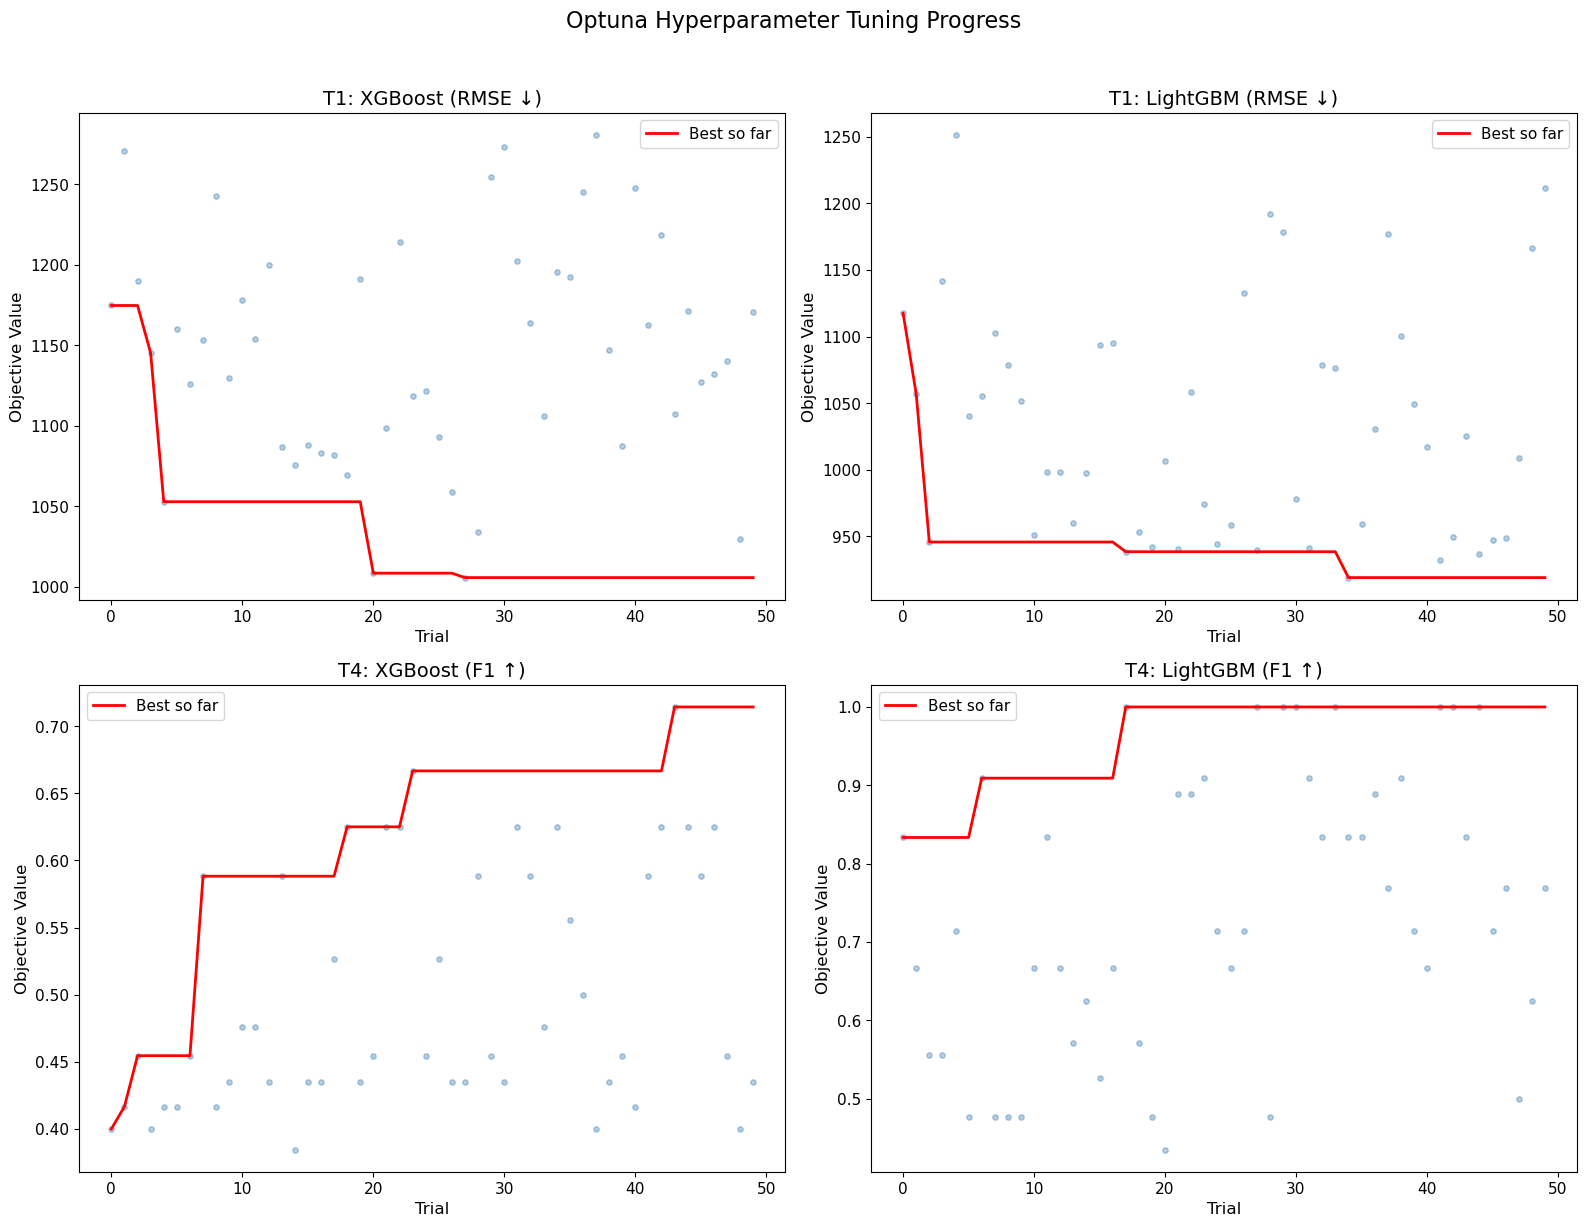

In [35]:
fig, axes = plt.subplots(2, 2, figsize = (16, 12))

studies = [
    (t1_xgb_study, 'T1: XGBoost (RMSE ↓)', axes[0, 0]),
    (t1_lgb_study, 'T1: LightGBM (RMSE ↓)', axes[0, 1]),
    (t4_xgb_study, 'T4: XGBoost (F1 ↑)', axes[1, 0]),
    (t4_lgb_study, 'T4: LightGBM (F1 ↑)', axes[1, 1])
]

for study, title, ax in studies:
    trials = study.trials
    values = [t.value for t in trials if t.value is not None]
    trial_nums = [t.number for t in trials if t.value is not None]

    ax.scatter(trial_nums, values, alpha = 0.4, s = 15, color = 'steelblue')

    if 'RMSE' in title:
        running_best = [min(values[:i+1]) for i in range(len(values))]
    else:
        running_best = [max(values[:i+1]) for i in range(len(values))]
    ax.plot(trial_nums, running_best, color = 'red', linewidth = 2, label = 'Best so far')

    ax.set_title(title)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Objective Value')
    ax.legend()

plt.suptitle('Optuna Hyperparameter Tuning Progress', fontsize = 16, y = 1.02)
plt.tight_layout()
plt.show()


#### Hyperparameter Importance (Optuna)

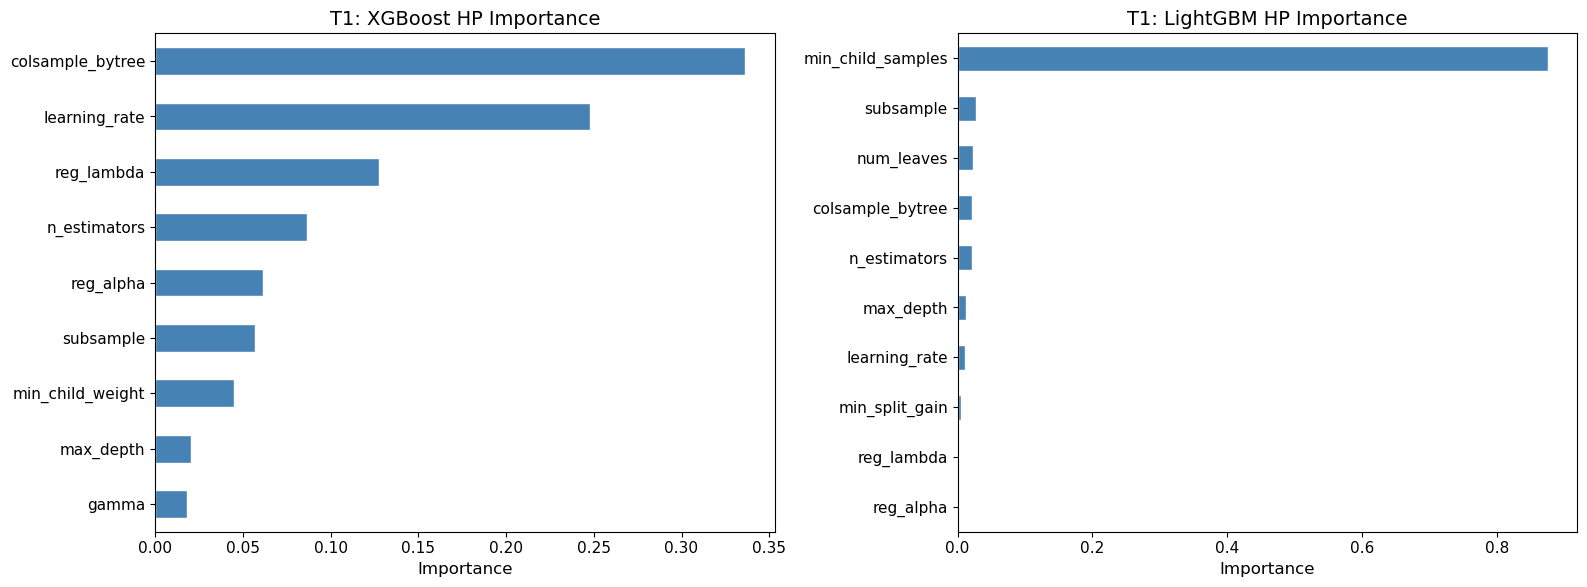

In [37]:
try:
    fig, axes = plt.subplots(1, 2, figsize = (16, 6))

    for study, title, ax in [
        (t1_xgb_study, 'T1: XGBoost HP Importance', axes[0]),
        (t1_lgb_study, 'T1: LightGBM HP Importance', axes[1])
    ]:
        try:
            importances = get_param_importances(study)
            imp_df = pd.Series(importances).sort_values()
            imp_df.plot(kind = 'barh', ax = ax, color = 'steelblue', edgecolor = 'white')
            ax.set_title(title)
            ax.set_xlabel('Importance')
        except Exception as e:
            ax.text(0.5, 0.5, f"Could not compute\n{e}", ha = 'center', va = 'center', transform = ax.transAxes)
            ax.set_title(title)

    plt.tight_layout()
    plt.show()

except ImportError:
    print('Optuna not installed')

```python
Dec 1-22 (Train)   │  Dec 23-27 (Val)   │  Dec 28-Jan 1 (Test)
     528 hours     │     120 hours      │      97 hours
                   │                    │
Normal weekdays +  │  Christmas!        │  NYE!
early Dec patterns │  Tests holiday     │  Tests extreme
                   │  generalization    │  surge events
```